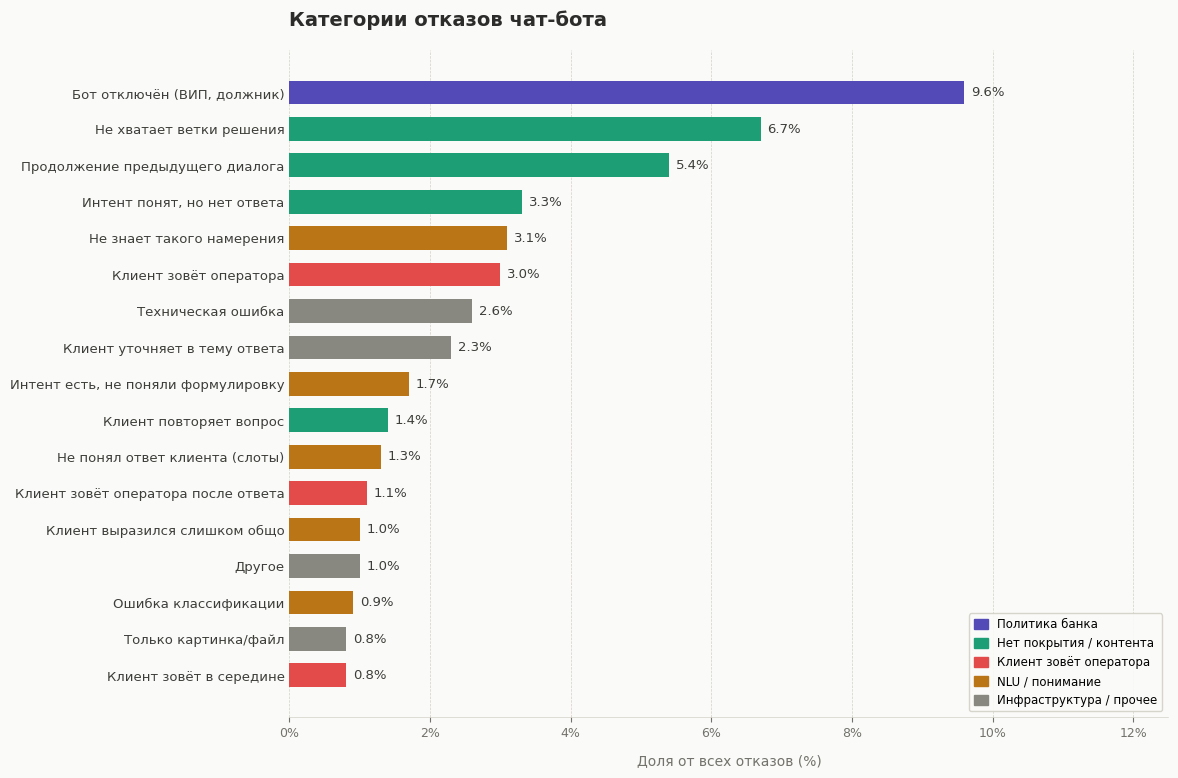

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

labels = [
    'Бот отключён (ВИП, должник)',
    'Не хватает ветки решения',
    'Продолжение предыдущего диалога',
    'Интент понят, но нет ответа',
    'Не знает такого намерения',
    'Клиент зовёт оператора',
    'Техническая ошибка',
    'Клиент уточняет в тему ответа',
    'Интент есть, не поняли формулировку',
    'Клиент повторяет вопрос',
    'Не понял ответ клиента (слоты)',
    'Клиент зовёт оператора после ответа',
    'Клиент выразился слишком общо',
    'Ошибка классификации',
    'Только картинка/файл',
    'Клиент зовёт в середине',
    'Другое',
]

values = [9.6, 6.7, 5.4, 3.3, 3.1, 3.0, 2.6, 2.3, 1.7, 1.4, 1.3, 1.1, 1.0, 0.9, 0.8, 0.8, 1.0]

color_map = {
    'Бот отключён (ВИП, должник)': '#534AB7',
    'Не хватает ветки решения': '#1D9E75',
    'Продолжение предыдущего диалога': '#BA7517',
    'Интент понят, но нет ответа': '#1D9E75',
    'Не знает такого намерения': '#1D9E75',
    'Клиент зовёт оператора': '#E24B4A',
    'Техническая ошибка': '#888780',
    'Клиент уточняет в тему ответа': '#888780',
    'Интент есть, не поняли формулировку': '#BA7517',
    'Клиент повторяет вопрос': '#1D9E75',
    'Не понял ответ клиента (слоты)': '#BA7517',
    'Клиент зовёт оператора после ответа': '#E24B4A',
    'Клиент выразился слишком общо': '#BA7517',
    'Ошибка классификации': '#BA7517',
    'Только картинка/файл': '#888780',
    'Клиент зовёт в середине': '#E24B4A',
    'Другое': '#888780',
}

colors = [color_map[l] for l in labels]

# Сортировка по убыванию
sorted_data = sorted(zip(values, labels, colors), reverse=True)
values_s, labels_s, colors_s = zip(*sorted_data)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

y_pos = np.arange(len(labels_s))
bars = ax.barh(y_pos, values_s, color=colors_s, height=0.65, zorder=3)

# Подписи значений
for bar, val in zip(bars, values_s):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f'{val}%', va='center', ha='left', fontsize=9.5,
            color='#3d3d3a', fontweight='500')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels_s, fontsize=9.5, color='#3d3d3a')
ax.invert_yaxis()

ax.set_xlabel('Доля от всех отказов (%)', fontsize=10, color='#73726c', labelpad=10)
ax.set_title('Категории отказов чат-бота', fontsize=14, fontweight='600',
             color='#2c2c2a', pad=18, loc='left')

ax.set_xlim(0, 12.5)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', colors='#73726c', labelsize=9)
ax.tick_params(axis='y', length=0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#d3d1c7')
ax.spines['bottom'].set_linewidth(0.5)

ax.xaxis.grid(True, color='#d3d1c7', linewidth=0.5, linestyle='--', zorder=0)
ax.set_axisbelow(True)

# Легенда
legend_items = [
    mpatches.Patch(color='#534AB7', label='Политика банка'),
    mpatches.Patch(color='#1D9E75', label='Нет покрытия / контента'),
    mpatches.Patch(color='#E24B4A', label='Клиент зовёт оператора'),
    mpatches.Patch(color='#BA7517', label='NLU / понимание'),
    mpatches.Patch(color='#888780', label='Инфраструктура / прочее'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8.5,
          frameon=True, framealpha=0.9, facecolor='#FAFAF8',
          edgecolor='#d3d1c7', handlelength=1.2, handleheight=0.9)

plt.tight_layout(pad=1.5)
plt.show()